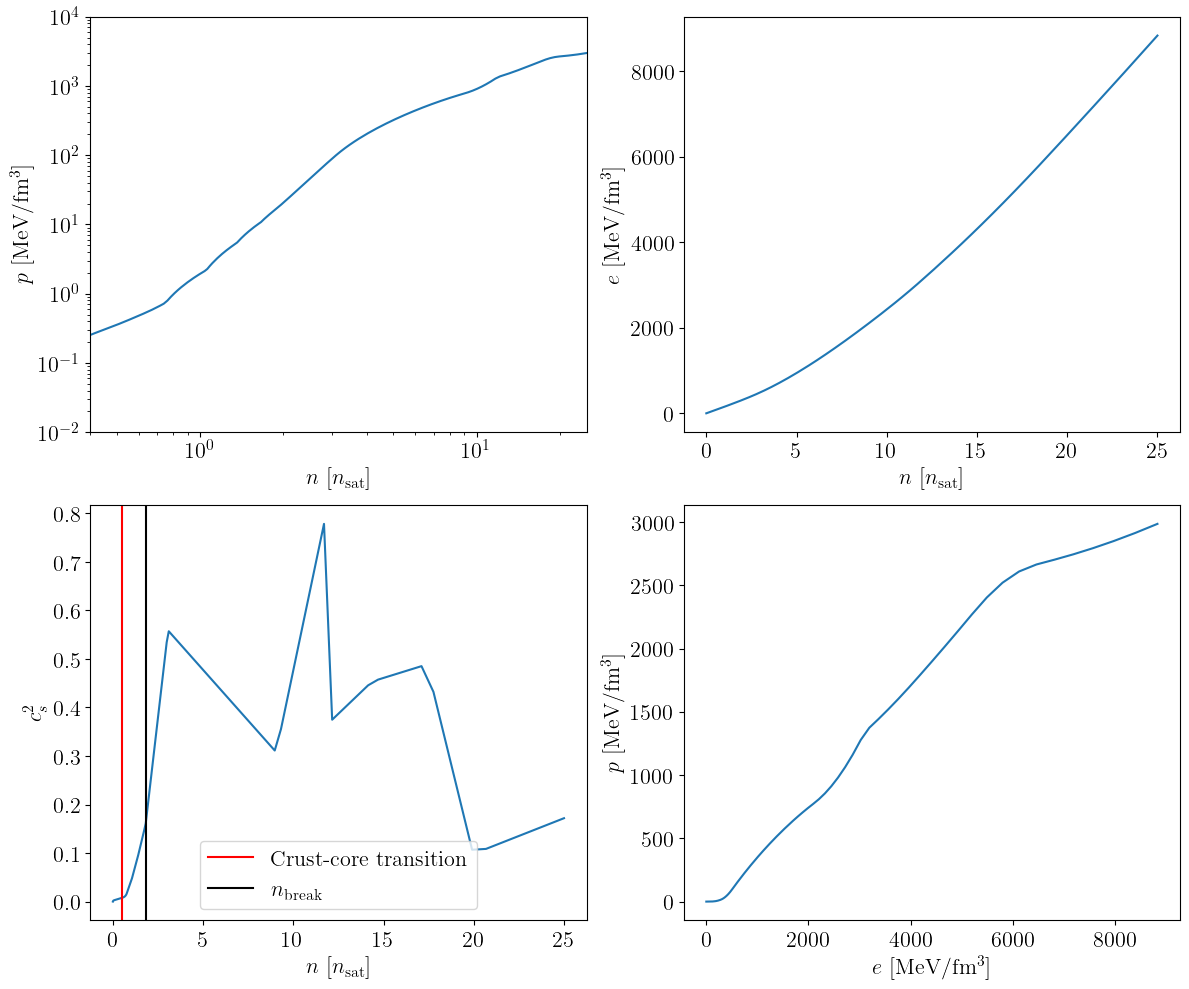

Running vmap for scalar-tensor calculations...
Scalar-tensor calculations for 1 beta values finished in 25.3335 seconds.


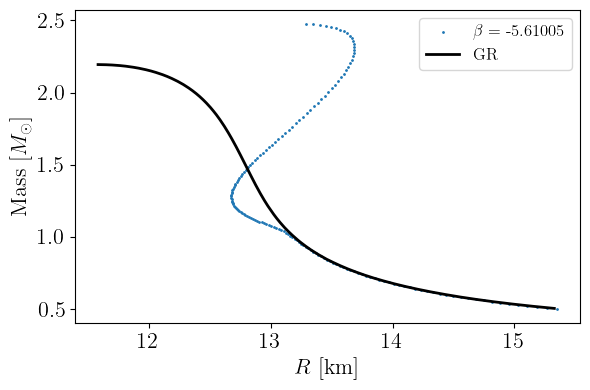

In [1]:
import matplotlib.pyplot as plt
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
params = {"text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"],
          "xtick.labelsize": 16,
          "ytick.labelsize": 16,
          "axes.labelsize": 16,
          "legend.fontsize": 16,
          "legend.title_fontsize": 16}
plt.rcParams.update(params)
import jax.numpy as jnp
import jax
from jax import config
config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
# from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model
# from jesterTOV.eos.families import construct_family, construct_family_nonGR, construct_family_ST, construct_family_ST_Greci, construct_family_ST_sol, construct_family_eibi
import jesterTOV.utils as utils
import time
from jesterTOV import utils
from jesterTOV.eos.metamodel import MetaModel_EOS_model, MetaModel_with_CSE_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver
# from jesterTOV.tov.eibi import EiBITOVSolver
from jesterTOV.tov.data_classes import EOSData



import jax.numpy as jnp                                                                                                   
import jax                                                                                                                
import matplotlib.pyplot as plt                                                                                           
import time                                                                                                               

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver


case_name = "case4"

if case_name == "case1":
    # Case 1. GR
    input_data_str = """
E_sat           | -1.59577e+01
E_sym           | 4.02592e+01
K_sat           | 2.81422e+02
K_sym           | -2.73364e+02
L_sym           | 2.97490e+01
Q_sat           | 4.71850e+02
Q_sym           | -4.54879e+02
Z_sat           | -1.15918e+03
Z_sym           | 3.16026e+02
_random_key     | 1.36150e+09
beta_ST         | -2.00280e+00
cs2_CSE_0       | 9.64526e-01
cs2_CSE_1       | 8.10706e-01
cs2_CSE_2       | 7.43328e-01
cs2_CSE_3       | 8.65659e-01
cs2_CSE_4       | 3.07420e-02
cs2_CSE_5       | 7.21023e-01
cs2_CSE_6       | 9.65283e-01
cs2_CSE_7       | 4.96315e-01
cs2_CSE_8       | 7.14064e-01
n_CSE_0_u       | 1.38456e-01
n_CSE_1_u       | 1.77157e-01
n_CSE_2_u       | 6.00186e-01
n_CSE_3_u       | 4.93667e-01
n_CSE_4_u       | 8.50130e-01
n_CSE_5_u       | 3.96461e-01
n_CSE_6_u       | 9.58902e-01
n_CSE_7_u       | 8.73815e-01
nbreak          | 2.16532e-01
phi_c           | 9.99953e-01
phi_inf_tgt     | 9.99978e-04
"""

elif case_name == "case2":
    # Case 2. ST Small bump
    input_data_str = """
E_sat           | -1.59577e+01
E_sym           | 4.02592e+01
K_sat           | 2.81422e+02
K_sym           | -2.73364e+02
L_sym           | 2.97490e+01
Q_sat           | 4.71850e+02
Q_sym           | -4.54879e+02
Z_sat           | -1.15918e+03
Z_sym           | 3.16026e+02
_random_key     | 1.36150e+09
beta_ST         | -4.80280e+00
cs2_CSE_0       | 9.64526e-01
cs2_CSE_1       | 8.10706e-01
cs2_CSE_2       | 7.43328e-01
cs2_CSE_3       | 8.65659e-01
cs2_CSE_4       | 3.07420e-02
cs2_CSE_5       | 7.21023e-01
cs2_CSE_6       | 9.65283e-01
cs2_CSE_7       | 4.96315e-01
cs2_CSE_8       | 7.14064e-01
n_CSE_0_u       | 1.38456e-01
n_CSE_1_u       | 1.77157e-01
n_CSE_2_u       | 6.00186e-01
n_CSE_3_u       | 4.93667e-01
n_CSE_4_u       | 8.50130e-01
n_CSE_5_u       | 3.96461e-01
n_CSE_6_u       | 9.58902e-01
n_CSE_7_u       | 8.73815e-01
nbreak          | 2.16532e-01
phi_c           | 9.99953e-01
phi_inf_tgt     | 9.99978e-04
"""

elif case_name == "case3":
    # CASE 3: ST with extreme mass - radius shift
    input_data_str = """
E_sat           | -1.60193e+01
E_sym           | 3.94645e+01
K_sat           | 1.89552e+02
K_sym           | -2.81984e+01
L_sym           | 1.82195e+01
Q_sat           | 1.54928e+02
Q_sym           | 1.22737e+03
Z_sat           | 1.45468e+03
Z_sym           | -7.32391e+01
_random_key     | 2.07058e+09
beta_ST         | -5.77032e+00
cs2_CSE_0       | 8.39565e-01
cs2_CSE_1       | 8.15221e-01
cs2_CSE_2       | 4.12762e-01
cs2_CSE_3       | 4.93620e-01
cs2_CSE_4       | 1.62055e-01
cs2_CSE_5       | 7.72167e-01
cs2_CSE_6       | 3.76947e-01
cs2_CSE_7       | 2.76801e-01
cs2_CSE_8       | 5.74852e-01
n_CSE_0_u       | 2.73534e-01
n_CSE_1_u       | 6.74102e-01
n_CSE_2_u       | 3.12529e-01
n_CSE_3_u       | 8.44386e-01
n_CSE_4_u       | 2.96292e-01
n_CSE_5_u       | 1.50952e-01
n_CSE_6_u       | 4.84994e-01
n_CSE_7_u       | 3.37661e-01
nbreak          | 2.24007e-01
phi_c           | 9.99935e-01
phi_inf_tgt     | 9.99955e-04
"""

elif case_name == "case4":
    # Case 4: ST with phase transition
    input_data_str = """E_sat           | -1.60667e+01
E_sym           | 3.92920e+01
K_sat           | 1.96292e+02
K_sym           | 9.83514e+01
L_sym           | 1.30970e+01
Q_sat           | 4.22457e+02
Q_sym           | -9.55569e+02
Z_sat           | -1.56207e+03
Z_sym           | 1.25714e+03
_random_key     | 3.97777e+09
beta_ST         | -5.61005e+00
cs2_CSE_0       | 5.58593e-01
cs2_CSE_1       | 3.07976e-01
cs2_CSE_2       | 7.96442e-01
cs2_CSE_3       | 5.40990e-01
cs2_CSE_4       | 3.73679e-01
cs2_CSE_5       | 4.53546e-01
cs2_CSE_6       | 4.88443e-01
cs2_CSE_7       | 9.81306e-02
cs2_CSE_8       | 1.71824e-01
n_CSE_0_u       | 5.41364e-01
n_CSE_1_u       | 4.44460e-01
n_CSE_2_u       | 7.82756e-01
n_CSE_3_u       | 4.30642e-01
n_CSE_4_u       | 6.71844e-01
n_CSE_5_u       | 5.33934e-02
n_CSE_6_u       | 4.40534e-01
n_CSE_7_u       | 3.11815e-01
nbreak          | 2.91341e-01
phi_c           | 9.99995e-01
phi_inf_tgt     | 9.99938e-04
"""
else:
    raise ValueError(f"Unknown case_name: {case_name}. Cek lagi dong kak! (⁠✿⁠ ⁠♡⁠‿⁠♡⁠)")

input_dict = {}
for line in input_data_str.strip().split('\n'):
    key, val = line.split('|')
    input_dict[key.strip()] = float(val.strip())

# Extract beta_ST for the TOV solver
beta_values = [input_dict.pop("beta_ST")]

nsat = 0.16 # nuclear saturation density in fm^-3
nmax_nsat = 25.0
nb_CSE = 8 # Updated to 8 to match the provided inputs (indices 0 to 8)

# Define the EOS object, here we focus on Metamodel with CSE
# Note: assuming MetaModel_with_CSE_EOS_model is imported or defined elsewhere in your workspace
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75, ndat_metamodel=80, ndat_CSE=70)

# Set the final grid density point explicitly as done in the original code
input_dict["n_CSE_8_u"] = nmax_nsat

# Now create the EOS, returns a tuple with most useful EOS quantities
eos_output = eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 = eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.xscale('log')
plt.yscale('log')
plt.xlim(4e-1,25)
plt.ylim(1e-2,10000)
# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# Parameters for TOV
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData 
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results, filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

# ============================================
# Plot 0: Mass vs Radius
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_radii, gr_masses, label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$ [km]")
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# # ============================================
# # Plot 1: Tensor tidal deformability Λ^T vs Mass
# # ============================================
# plt.figure(figsize=(6, 4))
# for beta_ST, data in results.items():
#     plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
# plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
# plt.xlabel(r"Mass [$M_\odot$]")
# plt.ylabel(r"$\Lambda^T$")
# plt.ylim(0, 6000)
# plt.xlim(0.5, 2.5)
# plt.legend(loc='upper right', fontsize=12)
# plt.tight_layout()
# plt.show()
# plt.close()

# # ============================================
# # Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# # ============================================
# plt.figure(figsize=(6, 4))
# for beta_ST, data in results.items():
#     plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
# plt.xlabel(r"Mass [$M_\odot$]")
# plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
# plt.ylim(0, 10)
# plt.xlim(0.5, 2.5)
# plt.legend(loc='upper right', fontsize=12)
# plt.tight_layout()
# plt.show()
# plt.close()

# # ============================================
# # Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# # ============================================
# plt.figure(figsize=(6, 4))
# for beta_ST, data in results.items():
#     plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
# plt.xlabel(r"Mass [$M_\odot$]")
# plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
# plt.ylim(-100, 0)
# plt.xlim(0.5, 2.5)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.show()
# plt.close()

# # ============================================
# # Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# # ============================================
# plt.figure(figsize=(6, 4))
# for beta_ST, data in results.items():
#     plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
# plt.xlabel(r"Mass [$M_\odot$]")
# plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
# plt.ylim(-100, 0)
# plt.xlim(0.5, 2.5)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.show()
# plt.close()

# # ============================================
# # Plot 5: Scalar charge q vs Mass
# # ============================================
# plt.figure(figsize=(6, 4))
# for beta_ST, data in results.items():
#   plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
# plt.xlabel(r"Mass [$M_\odot$]")
# plt.ylabel(r"$q$")
# plt.xlim(0.5, 2.5)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.show()
# plt.close()

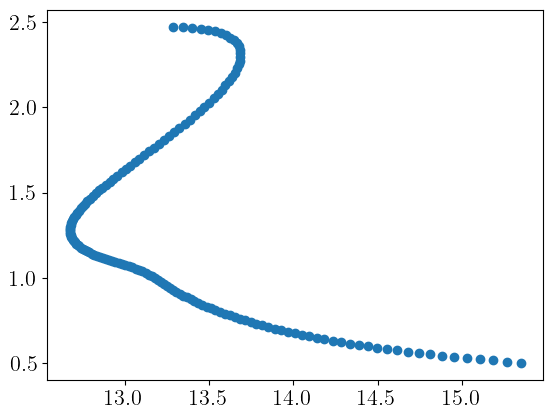

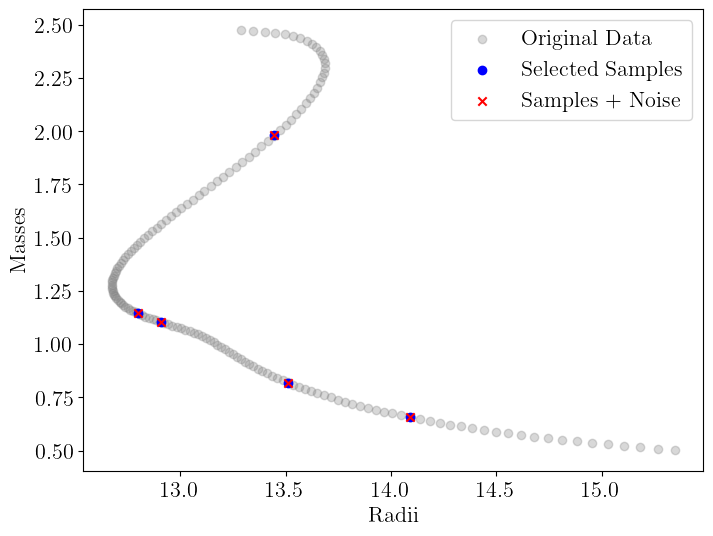

=== Sample Parameters Table ===
 Sample Mass_Center Radius_Center Mass_Center_Noise Radius_Center_Noise Std_Mass Std_Radius Covariance Skew_Mass Skew_Radius
      1       1.145        12.799             1.145              12.799    0.036      0.621      0.016     0.592      -2.064
      2       1.980        13.446             1.980              13.446    0.049      0.292      0.012     0.607       1.248
      3       1.104        12.910             1.104              12.910    0.023      0.634      0.012    -1.726      -1.909
      4       0.820        13.514             0.820              13.514    0.021      0.394      0.004    -0.408      -1.253
      5       0.657        14.093             0.657              14.093    0.025      0.341      0.003    -0.802      -0.264



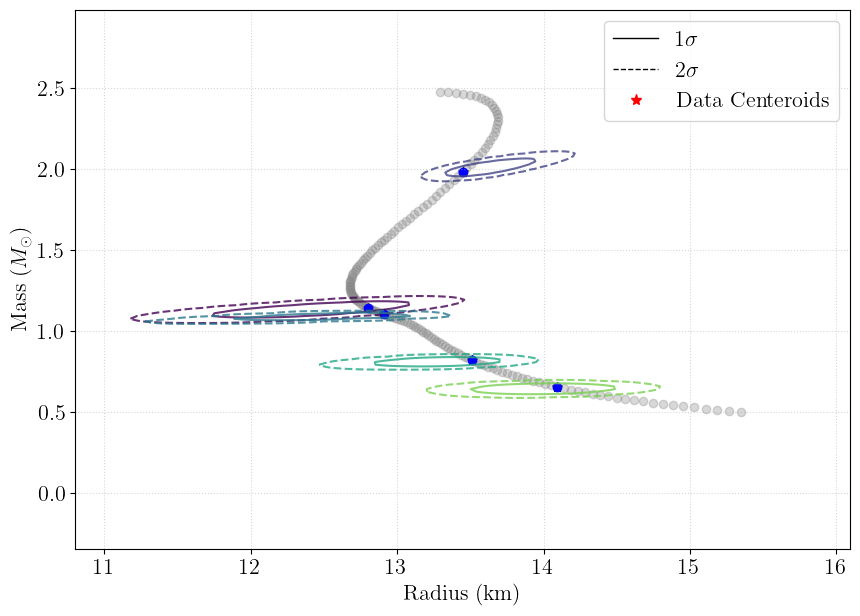

Done! Files saved as: case4_5ndat.csv and case4_params.txt (⁠づ⁠￣⁠ ⁠³⁠￣⁠)⁠づ
Initializing Likelihood module...
Evaluating provided EOS curve...
Total Normalized Log-Likelihood: -0.0643

Rendering probability contours...


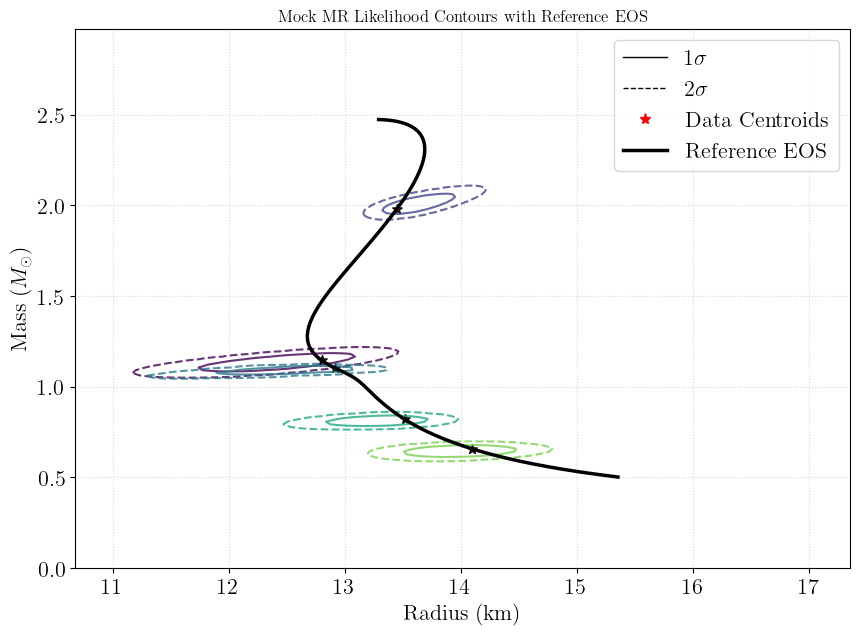

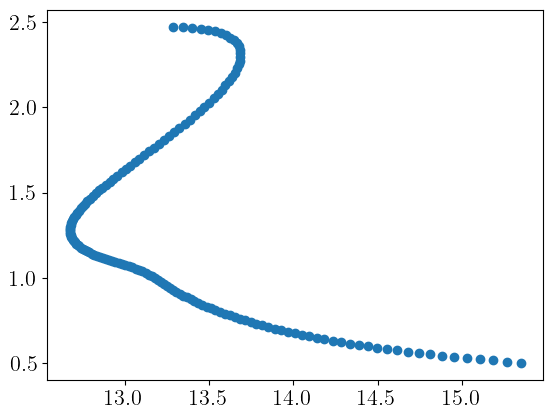

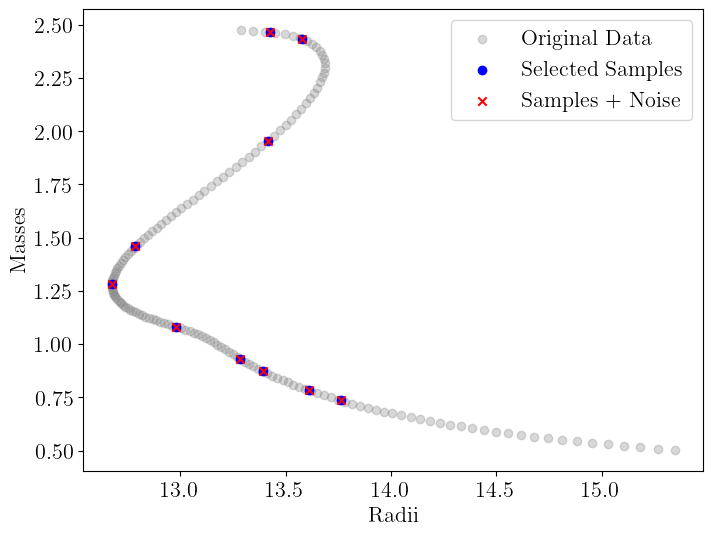

=== Sample Parameters Table ===
 Sample Mass_Center Radius_Center Mass_Center_Noise Radius_Center_Noise Std_Mass Std_Radius Covariance Skew_Mass Skew_Radius
      1       2.466        13.426             2.466              13.426    0.077      0.651      0.037     0.592      -2.064
      2       2.432        13.580             2.432              13.580    0.060      0.295      0.015     0.607       1.248
      3       0.932        13.284             0.932              13.284    0.019      0.652      0.010    -1.726      -1.909
      4       1.956        13.419             1.956              13.419    0.050      0.391      0.010    -0.408      -1.253
      5       0.874        13.392             0.874              13.392    0.034      0.324      0.003    -0.802      -0.264
      6       1.459        12.787             1.459              12.787    0.064      0.332      0.011     0.554      -2.721
      7       0.736        13.761             0.736              13.761    0.028      0.346  

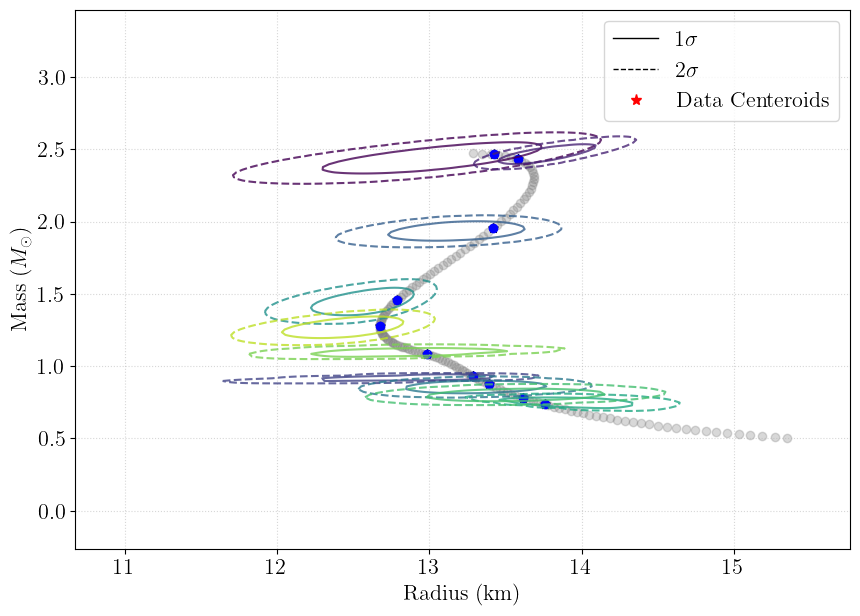

Done! Files saved as: case4_10ndat.csv and case4_params.txt (⁠づ⁠￣⁠ ⁠³⁠￣⁠)⁠づ
Initializing Likelihood module...
Evaluating provided EOS curve...
Total Normalized Log-Likelihood: -0.0983

Rendering probability contours...


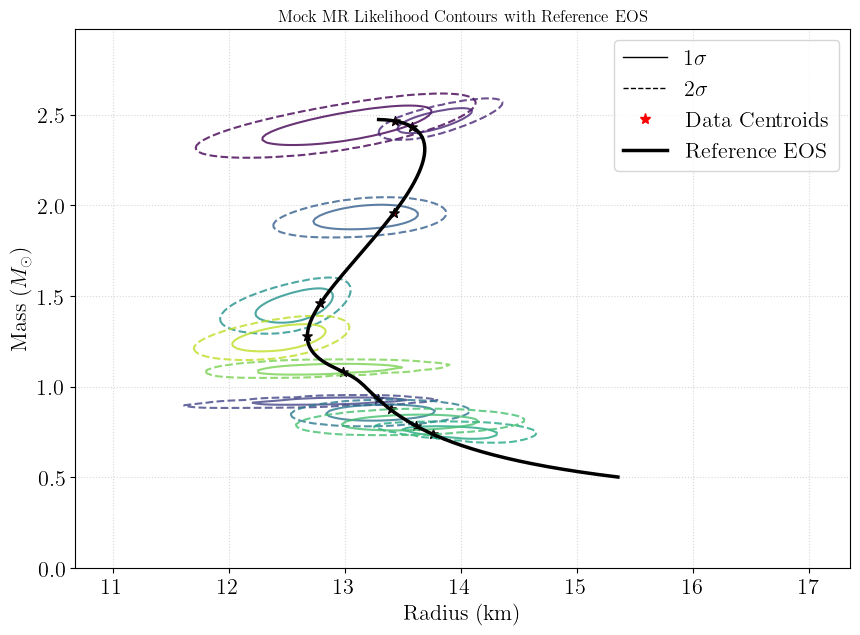

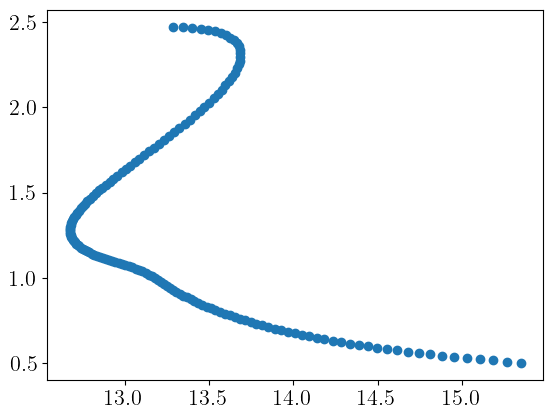

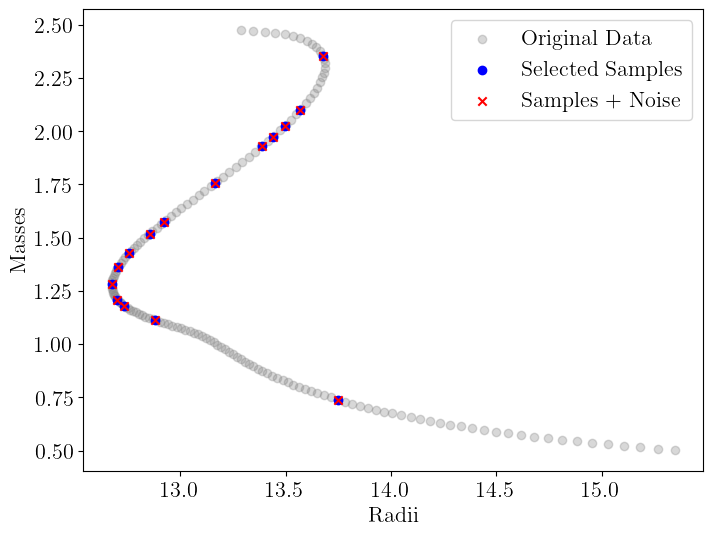

=== Sample Parameters Table ===
 Sample Mass_Center Radius_Center Mass_Center_Noise Radius_Center_Noise Std_Mass Std_Radius Covariance Skew_Mass Skew_Radius
      1       0.739        13.750             0.739              13.750    0.023      0.667      0.011     0.592      -2.064
      2       1.361        12.704             1.361              12.704    0.034      0.276      0.008     0.607       1.248
      3       1.113        12.882             1.113              12.882    0.023      0.632      0.012    -1.726      -1.909
      4       1.428        12.757             1.428              12.757    0.036      0.372      0.007    -0.408      -1.253
      5       1.283        12.675             1.283              12.675    0.049      0.307      0.004    -0.802      -0.264
      6       1.181        12.734             1.181              12.734    0.051      0.331      0.009     0.554      -2.721
      7       2.025        13.497             2.025              13.497    0.077      0.339  

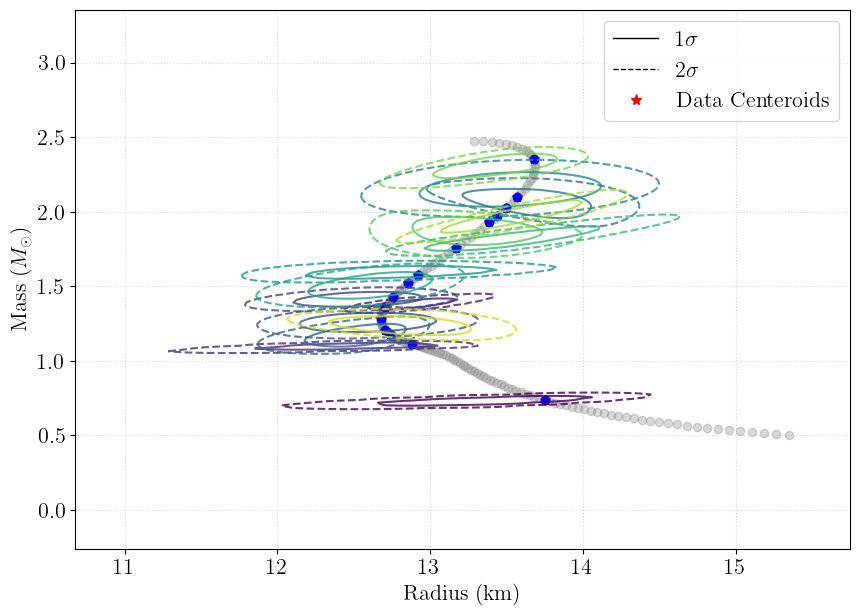

Done! Files saved as: case4_15ndat.csv and case4_params.txt (⁠づ⁠￣⁠ ⁠³⁠￣⁠)⁠づ
Initializing Likelihood module...
Evaluating provided EOS curve...
Total Normalized Log-Likelihood: 0.0804

Rendering probability contours...


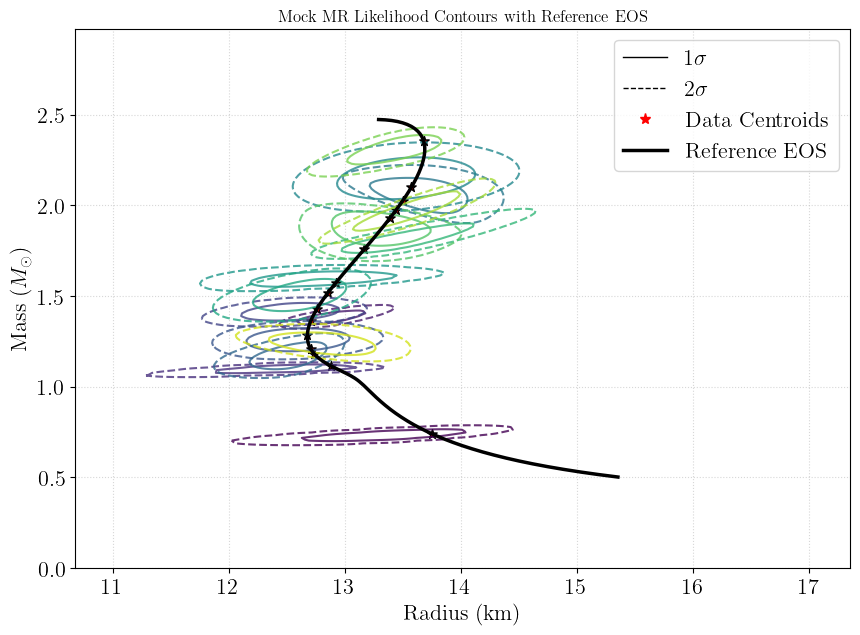

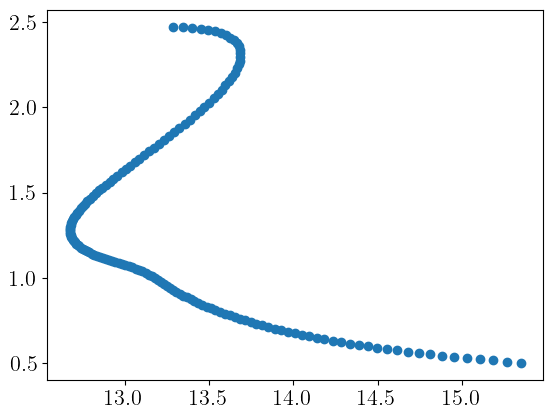

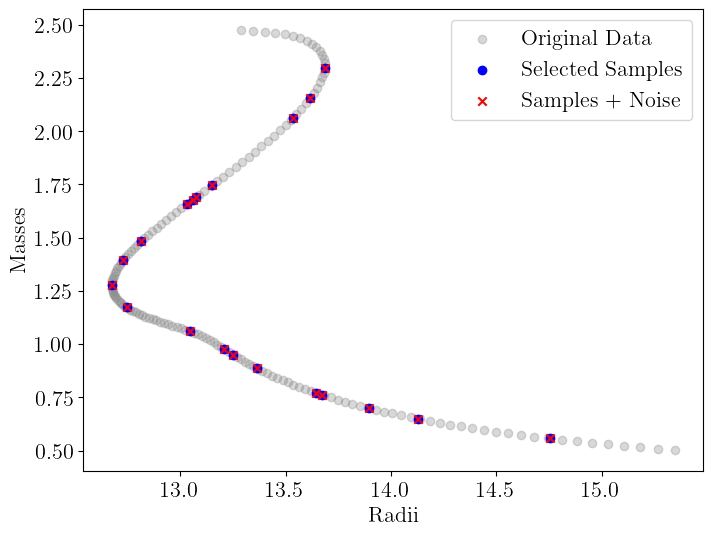

=== Sample Parameters Table ===
 Sample Mass_Center Radius_Center Mass_Center_Noise Radius_Center_Noise Std_Mass Std_Radius Covariance Skew_Mass Skew_Radius
      1       0.772        13.644             0.772              13.644    0.024      0.662      0.012     0.592      -2.064
      2       0.978        13.207             0.978              13.207    0.024      0.287      0.006     0.607       1.248
      3       0.701        13.895             0.701              13.895    0.014      0.682      0.008    -1.726      -1.909
      4       1.398        12.730             1.398              12.730    0.036      0.371      0.007    -0.408      -1.253
      5       1.277        12.675             1.277              12.675    0.049      0.307      0.004    -0.802      -0.264
      6       0.950        13.252             0.950              13.252    0.041      0.344      0.007     0.554      -2.721
      7       2.155        13.617             2.155              13.617    0.082      0.342  

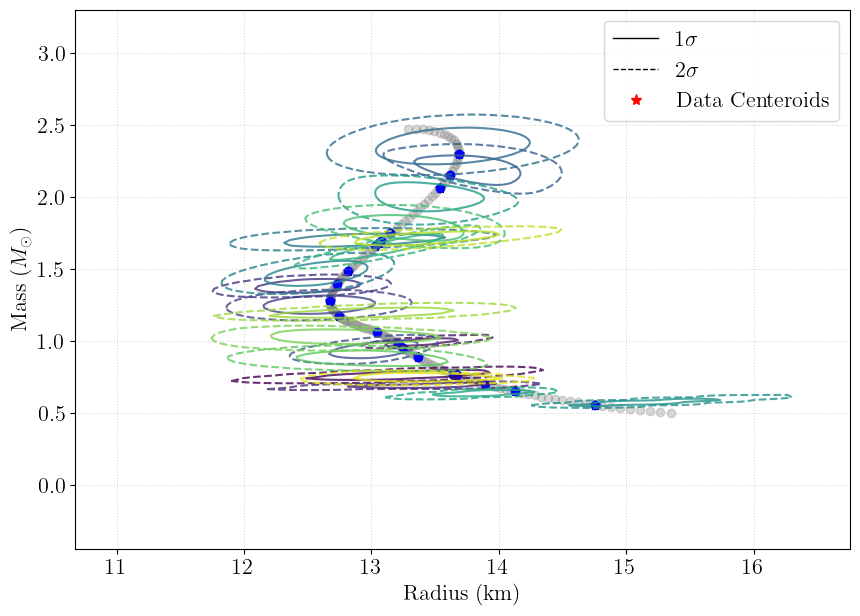

Done! Files saved as: case4_20ndat.csv and case4_params.txt (⁠づ⁠￣⁠ ⁠³⁠￣⁠)⁠づ
Initializing Likelihood module...
Evaluating provided EOS curve...
Total Normalized Log-Likelihood: -0.0652

Rendering probability contours...


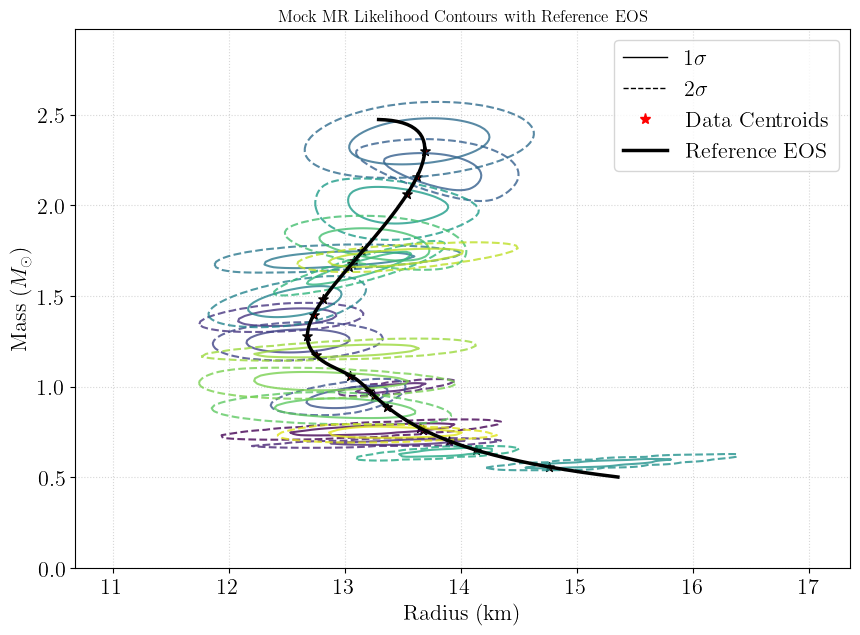

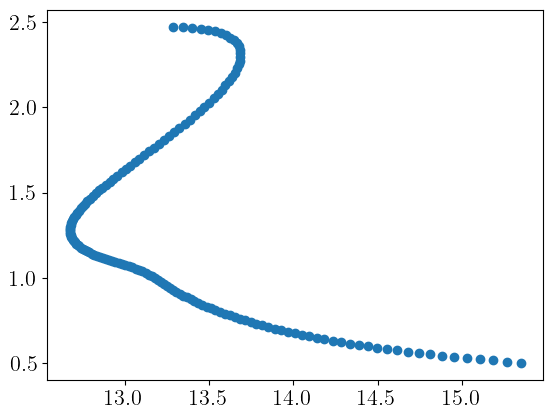

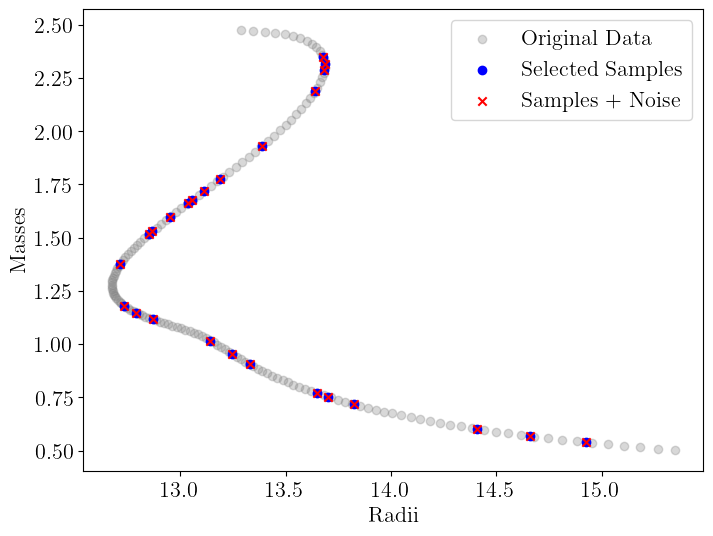

=== Sample Parameters Table ===
 Sample Mass_Center Radius_Center Mass_Center_Noise Radius_Center_Noise Std_Mass Std_Radius Covariance Skew_Mass Skew_Radius
      1       2.286        13.684             2.286              13.684    0.071      0.664      0.035     0.592      -2.064
      2       1.515        12.850             1.515              12.850    0.037      0.279      0.009     0.607       1.248
      3       1.531        12.869             1.531              12.869    0.032      0.632      0.017    -1.726      -1.909
      4       1.774        13.187             1.774              13.187    0.045      0.384      0.009    -0.408      -1.253
      5       1.661        13.035             1.661              13.035    0.064      0.315      0.006    -0.802      -0.264
      6       1.677        13.057             1.677              13.057    0.073      0.339      0.013     0.554      -2.721
      7       1.378        12.715             1.378              12.715    0.053      0.319  

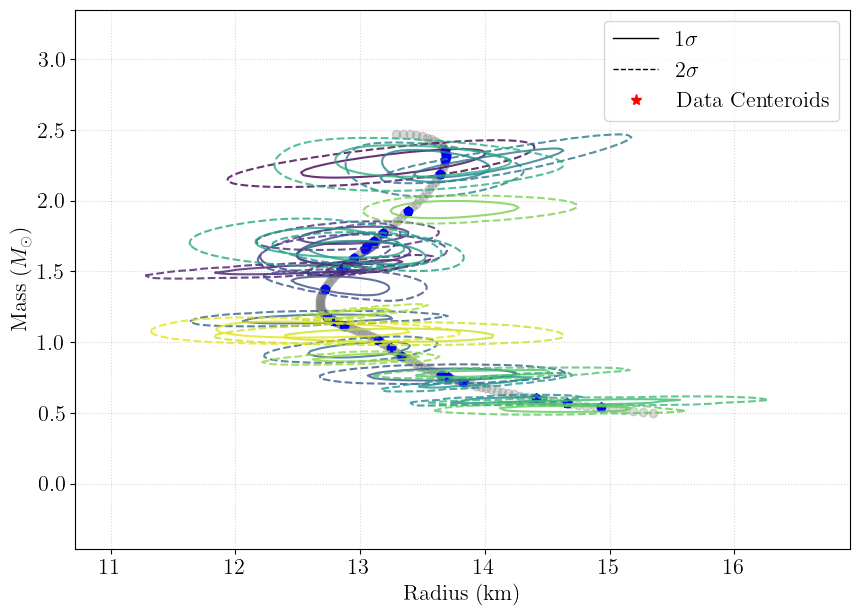

Done! Files saved as: case4_25ndat.csv and case4_params.txt (⁠づ⁠￣⁠ ⁠³⁠￣⁠)⁠づ
Initializing Likelihood module...
Evaluating provided EOS curve...
Total Normalized Log-Likelihood: -0.0849

Rendering probability contours...


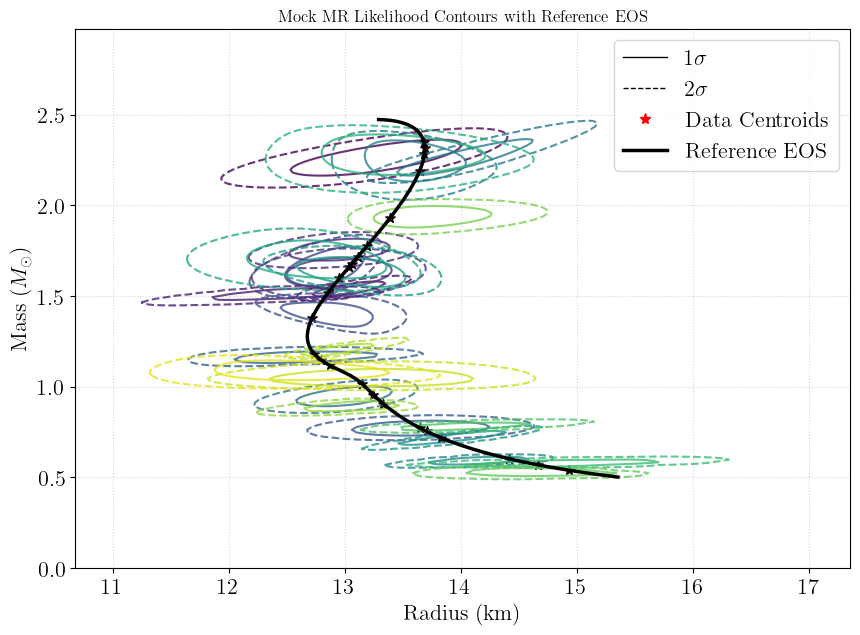

In [2]:
N_obj_list = [5, 10, 15, 20, 25]
for N_obj in N_obj_list:
    ######################################
    from jax import random
    
    key = jax.random.PRNGKey(43)
    
    n_data = data["radii"].shape[0]
    
    split_idx = int(utils.get_MR_split_index(data["radii"],data["masses"]))
    
    # Slice directly
    rad_seg1, rad_seg2 = data["radii"][:split_idx], data["radii"][split_idx:]
    mass_seg1, mass_seg2 = data["masses"][:split_idx], data["masses"][split_idx:]
    plt.scatter(rad_seg1,mass_seg1)
    plt.scatter(rad_seg2,mass_seg2)
    plt.show()
    
    key, subkey_u, subkey_coin = jax.random.split(key, 3)
    
    # idea: uniform mass distribution, but when mass is overlapping between segments, give 50:50 chance 
    # Handle if no phase transition
    if len(mass_seg2) == 0:
        m1_min, m1_max = mass_seg1[0], mass_seg1[-1]
        
        # Split key for uniformity
        key, subkey_u = jax.random.split(key, 2)
        sample_masses = jax.random.uniform(subkey_u, shape=(N_obj,), minval=m1_min, maxval=m1_max)
        sample_radii = jnp.interp(sample_masses, mass_seg1, rad_seg1)
    
    else:
        m1_min, m1_max = mass_seg1[0], mass_seg1[-1]
        m2_min, m2_max = mass_seg2[0], mass_seg2[-1]
    
        # Split key into 4 subkeys to account for the dirty injection
        key, subkey_u, subkey_coin, subkey_force = jax.random.split(key, 4)
    
        cond = m1_min <= m2_min
        min_a = jnp.where(cond, m1_min, m2_min)
        max_a = jnp.where(cond, m1_max, m2_max)
        min_b = jnp.where(cond, m2_min, m1_min)
        max_b = jnp.where(cond, m2_max, m1_max)
    
        is_gap = min_b > max_a
        width_a = max_a - min_a
        width_b = max_b - min_b
    
        total_domain_width = jnp.where(
            is_gap,
            width_a + width_b,
            jnp.maximum(max_a, max_b) - min_a
        )
    
        u = jax.random.uniform(subkey_u, shape=(N_obj,), minval=0.0, maxval=total_domain_width)
    
        mass_if_gap = jnp.where(u <= width_a, min_a + u, min_b + (u - width_a))
        mass_if_overlap = min_a + u
    
        sample_masses = jnp.where(is_gap, mass_if_gap, mass_if_overlap)
    
        r1 = jnp.interp(sample_masses, mass_seg1, rad_seg1)
        r2 = jnp.interp(sample_masses, mass_seg2, rad_seg2)
    
        valid1 = (sample_masses >= m1_min) & (sample_masses <= m1_max)
        valid2 = (sample_masses >= m2_min) & (sample_masses <= m2_max)
    
        coin_flip = jax.random.bernoulli(subkey_coin, p=0.5, shape=(N_obj,))
        use_seg1 = jnp.where(valid1 & valid2, coin_flip, valid1)
    
        sample_radii = jnp.where(use_seg1, r1, r2)
    
        # --- THE DIRTY BUSINESS ---
        
        # 1. Check if segment 2 was completely missed
        # ~use_seg1 is True for points assigned to segment 2
        missed_seg2 = jnp.all(use_seg1)
    
        # 2. Generate a guaranteed fallback point strictly in segment 2
        forced_m2 = jax.random.uniform(subkey_force, shape=(), minval=m2_min, maxval=m2_max)
        forced_r2 = jnp.interp(forced_m2, mass_seg2, rad_seg2)
    
        # 3. Create a mask to overwrite exactly one index (the last one) if needed
        overwrite_mask = (jnp.arange(N_obj) == (N_obj - 1)) & missed_seg2
    
        # 4. Apply the forced injection
        sample_masses = jnp.where(overwrite_mask, forced_m2, sample_masses)
        sample_radii = jnp.where(overwrite_mask, forced_r2, sample_radii)
    
    # Proceed to noise addition and plotting
    key_r, key_m = random.split(key, 2)
    
    std_m = jax.random.uniform(key_m, shape=sample_masses.shape, dtype=None, minval=0.02, maxval=0.05)
    std_r = jax.random.uniform(key_r, shape=sample_radii.shape, dtype=None, minval=0.02, maxval=0.05)
    
    delta_r = std_r * sample_radii
    delta_m = std_m * sample_masses
    
    noise_r = random.normal(key_r, shape=sample_radii.shape) * delta_r
    noise_m = random.normal(key_m, shape=sample_masses.shape) * delta_m

    #################################
    ####TURN OFF SYSTEMATIC NOISE#####
    noise_r, noise_m = 0,0

    #################################
    sample_radii_noise = sample_radii + noise_r
    sample_masses_noise = sample_masses + noise_m
    
    # Visualisasi
    plt.figure(figsize=(8, 6))
    plt.scatter(data["radii"], data["masses"], alpha=0.3, label="Original Data", color='gray')
    plt.scatter(sample_radii, sample_masses, label="Selected Samples", color='blue')
    plt.scatter(sample_radii_noise, sample_masses_noise, label="Samples + Noise", color='red', marker='x')
    plt.legend()
    plt.xlabel("Radii")
    plt.ylabel("Masses")
    plt.show()
    
    import jax
    import jax.numpy as jnp
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    
    class SkewedCorrelatedFlow:
        def __init__(self, m_center, r_center, cov_matrix, skewness):
            """
            m_center, r_center: Mean (2,)
            cov_matrix: Covariance matrix (2, 2) - Must be Positive Definite.
            skewness: Skewness vector (2,)
            """
            self.center = jnp.array([m_center, r_center])
            self.cov = jnp.array(cov_matrix)
            self.skew = jnp.array(skewness)
            
            # Precompute precision (inverse cov) and constant for log_prob
            self.inv_cov = jnp.linalg.inv(self.cov)
            self.log_det_cov = jnp.linalg.slogdet(self.cov)[1]
    
        def log_prob(self, mr_point):
            # mr_point shape: (..., 2)
            diff = mr_point - self.center
            
            # 1. Standard Multivariate Normal Part
            # REMEMBER: diff contains M and R, so need @ operation
            quad_form = jnp.sum(diff @ self.inv_cov * diff, axis=-1)
            log_norm = -0.5 * (self.log_det_cov + quad_form + 2 * jnp.log(2 * jnp.pi))
            
            # 2. Skewness Part
            omega = jnp.sqrt(jnp.diag(self.cov))
            alpha_prime = self.skew / omega
            
            skew_arg = jnp.sum(alpha_prime * diff, axis=-1)
            log_skew = jnp.log(2.0) + jax.scipy.stats.norm.logcdf(skew_arg)
            
            return log_norm + log_skew
    
    # Dummy data generation (assuming these were your inputs)
    np.random.seed(42) # For reproducible random parameter generation
    n_samples = len(sample_masses_noise)
    
    
    flows = []
    table_data = []
    
    # Generate different deviation, covariance, and skew for each sample
    for i, (m, r) in enumerate(zip(sample_masses_noise, sample_radii_noise)):
        # Random standard deviations and correlation
        std_m = np.random.uniform(0.02, 0.05) * m 
        std_r = np.random.uniform(0.02, 0.05) * r
        corr = np.random.uniform(0, 1) # Bounded to ensure positive definiteness
        
        # Construct covariance matrix
        cov_val = corr * std_m * std_r
        cov_m = jnp.array([
            [std_m**2, cov_val], 
            [cov_val,  std_r**2]
        ])
        
        # Random skewness
        skew_v = jnp.array([np.random.uniform(-3.0, 3.0), np.random.uniform(-3.0, 3.0)])
        
        # Initialize flow
        flows.append(SkewedCorrelatedFlow(m, r, cov_m, skew_v))
         
        # Store parameters for the table
        table_data.append({
            "Sample": i + 1,
            "Mass_Center": f"{sample_masses[i]:.3f}",
            "Radius_Center": f"{sample_radii[i]:.3f}",
            "Mass_Center_Noise": f"{m:.3f}",
            "Radius_Center_Noise": f"{r:.3f}",
            "Std_Mass": f"{std_m:.3f}",
            "Std_Radius": f"{std_r:.3f}",
            "Covariance": f"{cov_val:.3f}",
            "Skew_Mass": f"{skew_v[0]:.3f}",
            "Skew_Radius": f"{skew_v[1]:.3f}"
        })
    
    # Print the parameter table
    df_params = pd.DataFrame(table_data)
    print("=== Sample Parameters Table ===")
    print(df_params.to_string(index=False))
    print("===============================\n")
    
    def plot_mock_flows_contours(flows, samples_m, samples_r):
        m_grid = jnp.linspace(jnp.min(samples_m) - 1, jnp.max(samples_m) + 1, 200)
        r_grid = jnp.linspace(jnp.min(samples_r) - 2, jnp.max(samples_r) + 2, 200)
        M, R = jnp.meshgrid(m_grid, r_grid)
        grid_points = jnp.stack([M, R], axis=-1)
    
        plt.figure(figsize=(10, 7))
        cmap = plt.get_cmap('viridis')
        n_flows = len(flows)
    
        for i, flow in enumerate(flows):
            color = cmap(i / n_flows)
            
            # 1. Evaluate probability
            lp = flow.log_prob(grid_points)
            prob = jnp.exp(lp)
            
            # 2. Sort descending
            prob_flat = prob.flatten()
            sorted_prob = jnp.sort(prob_flat)[::-1]
            
            # 3. Accumulate and normalize to exactly 1 over the grid
            cum_prob = jnp.cumsum(sorted_prob)
            cum_prob = cum_prob / cum_prob[-1] 
            
            # 4. Identify thresholds for 1-sigma (68.27%) and 2-sigma (95.45%)
            idx_1sigma = jnp.searchsorted(cum_prob, 0.6827)
            idx_2sigma = jnp.searchsorted(cum_prob, 0.9545)
            
            level_1sigma = sorted_prob[idx_1sigma]
            level_2sigma = sorted_prob[idx_2sigma]
            
            # 5. Draw contours
            plt.contour(R, M, prob, levels=[level_2sigma, level_1sigma], 
                        colors=[color], alpha=0.8, linestyles=['dashed', 'solid'])
            
            # Corrected Center Plotting
            plt.scatter(flow.center[1], flow.center[0], color='red', 
                        marker='*', s=50, edgecolors='black', 
                        label='Data Centers' if i == 0 else "")
        plt.scatter(data["radii"], data["masses"], alpha=0.3, label="Reference masses radii", color='gray')
        plt.scatter(sample_radii, sample_masses, label="Selected Samples", color='blue')
        plt.ylabel(r"Mass ($M_{\odot}$)")
        plt.xlabel("Radius (km)")
        plt.grid(True, linestyle=':', alpha=0.5)
        
        # Custom legend for contour lines
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='black', lw=1, linestyle='solid'),
                        Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
                        Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=8)]
        plt.legend(custom_lines, [r'$1\sigma$', r'$2\sigma$', 'Data Centeroids'])
        plot_filename = f"{case_name}_{N_obj}ndat_plot.pdf"
        plt.savefig(plot_filename, format='pdf', bbox_inches='tight')
        plt.show()
    
    # Execute plot
    plot_mock_flows_contours(flows, sample_masses_noise, sample_radii_noise)
    # Convert list of dicts to DataFrame
    df_params = pd.DataFrame(table_data)
    
    csv_filename = f"{case_name}_{N_obj}ndat.csv"
    params_filename = f"{case_name}_params.txt"
    
    with open(params_filename, "w") as f:
        f.write(input_data_str)
    df_params.to_csv(csv_filename, index=False)
    
    print(f"Done! Files saved as: {csv_filename} and {params_filename} (⁠づ⁠￣⁠ ⁠³⁠￣⁠)⁠づ")
    
    import jax
    import jax.numpy as jnp
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from jax.scipy.stats import norm
    from jax.scipy.special import logsumexp
    
    # ==============================================================================
    # 0. MOCK INFRASTRUCTURE (To make this script standalone)
    # ==============================================================================
    class LikelihoodBase:
        pass
    
    
    
    
    # ==============================================================================
    # 1. ACTUAL CLASS IMPLEMENTATION (For integration into Jester)
    # ==============================================================================
    class MockMRLikelihood(LikelihoodBase):
        """
        Mock MR Likelihood evaluating deterministic skewed correlated posteriors.
        Integrates probability density over a mass grid and normalizes by K samples correctly in log-space.
        """
        def __init__(
            self, 
            csv_file: str, 
            penalty_value: float = -1e10, 
            N_masses_evaluation: int = 200
        ) -> None:
            super().__init__()
            self.penalty_value = penalty_value
            self.N_masses_evaluation = N_masses_evaluation
    
            # Parse CSV
            df = pd.read_csv(csv_file)
            self.K = len(df)
            
            # Only parse necessary information as requested (Noise centers)
            self.centers = jnp.array(df[["Mass_Center_Noise", "Radius_Center_Noise"]].values)
            std_m = jnp.array(df["Std_Mass"].values)
            std_r = jnp.array(df["Std_Radius"].values)
            cov_val = jnp.array(df["Covariance"].values)
            self.skews = jnp.array(df[["Skew_Mass", "Skew_Radius"]].values)
    
            # Build Covariance matrices (K, 2, 2)
            covs = np.zeros((self.K, 2, 2))
            covs[:, 0, 0] = std_m**2
            covs[:, 1, 1] = std_r**2
            covs[:, 0, 1] = cov_val
            covs[:, 1, 0] = cov_val
            self.covs = jnp.array(covs)
    
            # Precompute heavy matrix operations for the flow
            self.inv_covs = jnp.linalg.inv(self.covs)
            self.log_det_covs = jnp.linalg.slogdet(self.covs)[1]
            
            # Precompute skew modifiers
            self.omegas = jnp.sqrt(jnp.diagonal(self.covs, axis1=1, axis2=2))
            self.alpha_primes = self.skews / self.omegas
    
        def evaluate(self, params: dict) -> float:
            masses_EOS = params["masses_EOS"]
            radii_EOS = params["radii_EOS"]
            mtov = jnp.max(masses_EOS)
    
            # Phase transition splitting logic
            split_idx = utils.get_MR_split_index(masses_EOS, radii_EOS)
            idx = jnp.arange(masses_EOS.shape[0])
            mask1 = idx < split_idx
            mask2 = idx >= split_idx
    
            # Segment 1 setup
            m_eos_1 = jnp.where(mask1, masses_EOS, jnp.inf)
            r_eos_1 = jnp.where(mask1, radii_EOS, 0.0)
            sort_1 = jnp.argsort(m_eos_1)
            m_eos_1, r_eos_1 = m_eos_1[sort_1], r_eos_1[sort_1]
            seg1_min = m_eos_1[0]
            seg1_max = jnp.max(jnp.where(m_eos_1 == jnp.inf, -jnp.inf, m_eos_1))
    
            # Segment 2 setup
            m_eos_2 = jnp.where(mask2, masses_EOS, jnp.inf)
            r_eos_2 = jnp.where(mask2, radii_EOS, 0.0)
            sort_2 = jnp.argsort(m_eos_2)
            m_eos_2, r_eos_2 = m_eos_2[sort_2], r_eos_2[sort_2]
            seg2_min = m_eos_2[0]
            seg2_max = jnp.max(jnp.where(m_eos_2 == jnp.inf, -jnp.inf, m_eos_2))
    
            # Uniform mass grid for deterministic numerical integration
            m_grid = jnp.linspace(0.1, 3.5, self.N_masses_evaluation)
            dm = m_grid[1] - m_grid[0]
    
            def compute_log_prob_segment(m_eos, r_eos, seg_min, seg_max):
                # Interpolate radius for the entire grid
                r_grid = jnp.interp(m_grid, m_eos, r_eos)
                mr_points = jnp.stack([m_grid, r_grid], axis=-1)  # (N, 2)
    
                # Vectorized multivariate evaluation over K samples and N points
                # diff shape: (K, N, 2)
                diff = mr_points[None, :, :] - self.centers[:, None, :]
                
                # Quadratic form via Einstein summation: (K, N)
                diff_transformed = jnp.einsum('kij,knj->kni', self.inv_covs, diff)
                quad_form = jnp.sum(diff * diff_transformed, axis=-1)
    
                # Normal part
                log_norm = -0.5 * (self.log_det_covs[:, None] + quad_form + 2 * jnp.log(2 * jnp.pi))
    
                # Skewness part
                skew_arg = jnp.sum(self.alpha_primes[:, None, :] * diff, axis=-1)
                log_skew = jnp.log(2.0) + norm.logcdf(skew_arg)
    
                log_prob = log_norm + log_skew
    
                # Discard out-of-segment points
                in_segment = (m_grid >= seg_min) & (m_grid <= seg_max)
                log_prob = jnp.where(in_segment[None, :], log_prob, -jnp.inf)
    
                # Apply TOV limit penalty
                penalty = jnp.where(m_grid > mtov, self.penalty_value, 0.0)
                log_prob = log_prob + penalty[None, :]
    
                return log_prob
    
            # Evaluate both segments
            log_prob_seg1 = compute_log_prob_segment(m_eos_1, r_eos_1, seg1_min, seg1_max)
            log_prob_seg2 = compute_log_prob_segment(m_eos_2, r_eos_2, seg2_min, seg2_max)
    
            # Recombine segments (Log addition handles disjoint domains naturally)
            log_prob_combined = jnp.logaddexp(log_prob_seg1, log_prob_seg2)
    
            # Marginalize over M (Numerical integration: sum(P * dm) -> logsumexp + log(dm))
            logL_individuals = logsumexp(log_prob_combined, axis=1) + jnp.log(dm)
    
            # Normalize by taking the log of the arithmetic mean of the likelihoods
            total_log_likelihood = logsumexp(logL_individuals) - jnp.log(self.K)
    
            return total_log_likelihood
    
    # ==============================================================================
    # 2. TESTING AND VISUALIZATION
    # ==============================================================================
    # ==============================================================================
    # 2. TESTING AND VISUALIZATION
    # ==============================================================================
    def plot_mock_likelihood(mock_ll, m_eos, r_eos):
        """Replicates the contour plotting logic using the highly-vectorized class variables"""
        # Define grid spanning the data space
        m_grid = jnp.linspace(0.0, jnp.max(m_eos) + 0.5, 200)
        r_grid = jnp.linspace(jnp.min(r_eos) - 2.0, jnp.max(r_eos) + 2.0, 200)
        M, R = jnp.meshgrid(m_grid, r_grid)
        grid_points = jnp.stack([M, R], axis=-1)
    
        plt.figure(figsize=(10, 7))
        cmap = plt.get_cmap('viridis')
    
        for k in range(mock_ll.K):
            color = cmap(k / mock_ll.K)
            
            # Vectorized probability extraction for grid
            diff = grid_points - mock_ll.centers[k]
            diff_transformed = jnp.einsum('ij,nmj->nmi', mock_ll.inv_covs[k], diff)
            quad = jnp.sum(diff * diff_transformed, axis=-1)
            
            log_norm = -0.5 * (mock_ll.log_det_covs[k] + quad + 2 * jnp.log(2 * jnp.pi))
            skew_arg = jnp.sum(mock_ll.alpha_primes[k] * diff, axis=-1)
            log_skew = jnp.log(2.0) + norm.logcdf(skew_arg)
            
            prob = jnp.exp(log_norm + log_skew)
    
            # Normalization for contours
            prob_flat = prob.flatten()
            sorted_prob = jnp.sort(prob_flat)[::-1]
            cum_prob = jnp.cumsum(sorted_prob)
            cum_prob = cum_prob / cum_prob[-1] 
    
            idx_1sigma = min(jnp.searchsorted(cum_prob, 0.6827), len(sorted_prob)-1)
            idx_2sigma = min(jnp.searchsorted(cum_prob, 0.9545), len(sorted_prob)-1)
    
            level_1sigma = sorted_prob[idx_1sigma]
            level_2sigma = sorted_prob[idx_2sigma]
    
            plt.contour(R, M, prob, levels=[float(level_2sigma), float(level_1sigma)], 
                        colors=[color], alpha=0.8, linestyles=['dashed', 'solid'])
            
            plt.scatter(mock_ll.centers[k, 1], mock_ll.centers[k, 0], color='red', 
                        marker='*', s=50, edgecolors='black', label='Data Centroids' if k == 0 else "")
    
        # Overlay True Reference EOS
        plt.plot(r_eos, m_eos, color='black', linewidth=2.5, zorder=10)
        
        plt.ylabel(r"Mass ($M_{\odot}$)")
        plt.xlabel("Radius (km)")
        plt.grid(True, linestyle=':', alpha=0.5)
        
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='black', lw=1, linestyle='solid'),
                        Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
                        Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=8),
                        Line2D([0], [0], color='black', lw=2.5, linestyle='solid')]
        plt.legend(custom_lines, [r'$1\sigma$', r'$2\sigma$', 'Data Centroids', 'Reference EOS'])
        plt.title("Mock MR Likelihood Contours with Reference EOS")
        plt.show()
    
    # Execution
    # Ensure 'data' is loaded in your environment before this point.
    # Example: data = np.load("reference_curve.npz") or similar
    
    print("Initializing Likelihood module...")
    mock_likelihood = MockMRLikelihood(csv_filename, N_masses_evaluation=300)
    
    print("Evaluating provided EOS curve...")
    m_eos = jnp.array(data["masses"])
    r_eos = jnp.array(data["radii"])
    params = {"masses_EOS": m_eos, "radii_EOS": r_eos}
    
    # Calculate 
    ll_val = mock_likelihood.evaluate(params)
    print(f"Total Normalized Log-Likelihood: {ll_val:.4f}\n")
    
    print("Rendering probability contours...")
    plot_mock_likelihood(mock_likelihood, m_eos, r_eos)